<a href="https://colab.research.google.com/github/sanchit-fintech/FinSight/blob/main/notebooks/01_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinSight — Data Collection

## Notebook 01

### Objective

The objective of this notebook is to collect historical stock market data for selected companies and prepare the initial raw dataset for the FinSight project.

### Pipeline

Company Selection → Data Collection → Data Inspection → Raw Dataset Storage

### Data Source

Yahoo Finance

---

This notebook is the first stage of the FinSight data pipeline.

In [1]:
# ============================================
# FINSIGHT — IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# FINSIGHT — SELECT COMPANIES
# ============================================

companies = {
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS",
    "Infosys": "INFY.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS"
}

print("Selected companies:")

for company in companies:
    print("-", company)

Selected companies:
- Reliance Industries
- Tata Consultancy Services
- Infosys
- HDFC Bank
- ICICI Bank


In [3]:
# ============================================
# FINSIGHT — DOWNLOAD RELIANCE STOCK DATA
# ============================================

# Define the stock ticker
ticker = "RELIANCE.NS"

# Download historical stock data from Yahoo Finance
reliance_data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01"
)

# Display the first 20 rows
print("FIRST 20 ROWS OF RELIANCE STOCK DATA")
display(reliance_data.head(5))

# Display the last 10 rows
print("LAST 10 ROWS OF RELIANCE STOCK DATA")
display(reliance_data.tail(5))

# Display the size of the dataset
print("\nDataset Shape:", reliance_data.shape)

# Display basic information
print("\nDataset Columns:")
print(reliance_data.columns)

/tmp/ipykernel_2391/28613053.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance_data = yf.download(
[*********************100%***********************]  1 of 1 completed

FIRST 20 ROWS OF RELIANCE STOCK DATA


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.483948,686.487774,678.183007,682.635940,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622


LAST 10 ROWS OF RELIANCE STOCK DATA


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-12-24,1212.280762,1222.988340,1210.545745,1211.834663,6734917
2024-12-26,1206.133911,1217.188348,1203.853555,1213.767935,10016178
2024-12-27,1210.595459,1217.386785,1206.580087,1207.869004,7000397
2024-12-30,1200.333984,1212.726960,1197.756270,1205.985254,8818766
2024-12-31,1205.043213,1208.661986,1195.822913,1197.657049,6405475



Dataset Shape: (1238, 5)

Dataset Columns:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


In [4]:
# ============================================
# FINSIGHT — UNDERSTAND STOCK DATA
# ============================================

# Display the column names
print("DATASET COLUMNS:")
print(reliance_data.columns)

print("\n" + "=" * 50)

# Display information about the dataset
print("DATASET INFORMATION:")
reliance_data.info()

print("\n" + "=" * 50)

# Display statistical summary
print("STATISTICAL SUMMARY:")
display(reliance_data.describe())

DATASET COLUMNS:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1238 non-null   float64
 1   (High, RELIANCE.NS)    1238 non-null   float64
 2   (Low, RELIANCE.NS)     1238 non-null   float64
 3   (Open, RELIANCE.NS)    1238 non-null   float64
 4   (Volume, RELIANCE.NS)  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB

STATISTICAL SUMMARY:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1095.098185,1107.006453,1084.237079,1095.962055,1.951391e+07
std,230.477782,230.698654,230.092009,230.365317,1.612248e+07
min,393.662384,423.029534,389.921900,407.978572,1.705656e+06
25%,951.000778,962.121251,942.435874,951.571376,1.009199e+07
50%,1115.586792,1127.810013,1106.010452,1116.995479,1.425293e+07
75%,1219.325348,1232.958612,1207.933170,1219.190519,2.203644e+07
max,1581.824463,1589.630354,1566.607971,1585.332124,1.426834e+08


In [5]:
# ============================================
# FINSIGHT — CHECK DATA QUALITY
# ============================================

# Check for missing values in each column
print("MISSING VALUES IN EACH COLUMN:")
print(reliance_data.isnull().sum())

print("\n" + "=" * 50)

# Check if the entire dataset contains any missing values
total_missing = reliance_data.isnull().sum().sum()

print("TOTAL MISSING VALUES:", total_missing)

print("\n" + "=" * 50)

# Display duplicate rows
duplicate_rows = reliance_data.duplicated().sum()

print("TOTAL DUPLICATE ROWS:", duplicate_rows)

MISSING VALUES IN EACH COLUMN:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

TOTAL MISSING VALUES: 0

TOTAL DUPLICATE ROWS: 0


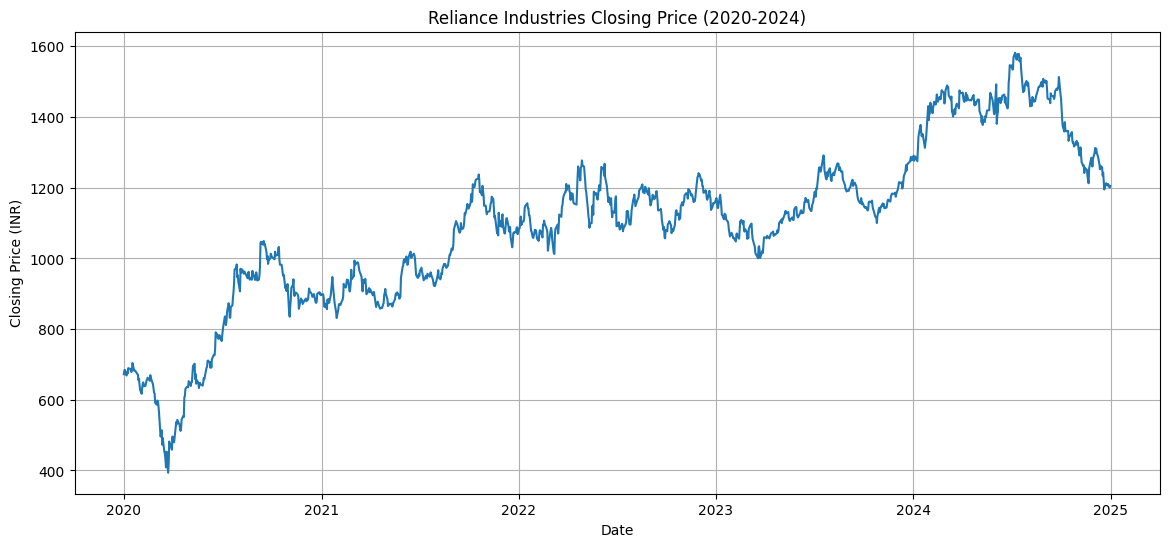

In [6]:
# ============================================
# FINSIGHT — VISUALIZE RELIANCE STOCK PRICE
# ============================================

import matplotlib.pyplot as plt

# Create the graph
plt.figure(figsize=(14, 6))

plt.plot(
    reliance_data.index,
    reliance_data["Close"]
)

# Add title and labels
plt.title("Reliance Industries Closing Price (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")

# Add grid
plt.grid(True)

# Display the graph
plt.show()

In [7]:
# ============================================
# FINSIGHT — BASIC STOCK INFORMATION
# ============================================

# Get the closing price column
close_prices = reliance_data["Close"]

# Calculate basic information
lowest_price = close_prices.min()
highest_price = close_prices.max()
average_price = close_prices.mean()

# Print the results
print("RELIANCE STOCK SUMMARY")
print("=" * 40)

print("Lowest Closing Price:", lowest_price)
print("Highest Closing Price:", highest_price)
print("Average Closing Price:", average_price)

RELIANCE STOCK SUMMARY
Lowest Closing Price: Ticker
RELIANCE.NS    393.662384
dtype: float64
Highest Closing Price: Ticker
RELIANCE.NS    1581.824463
dtype: float64
Average Closing Price: Ticker
RELIANCE.NS    1095.098185
dtype: float64


In [8]:
# ============================================
# FINSIGHT — UNDERSTAND DATA STRUCTURE
# ============================================

# Print the complete column structure
print("COLUMN STRUCTURE:")
print(reliance_data.columns)

print("\nColumn levels:", reliance_data.columns.nlevels)

print("\nDataset preview:")
display(reliance_data.head())

COLUMN STRUCTURE:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

Column levels: 2

Dataset preview:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.483948,686.487774,678.183007,682.635940,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622


In [9]:
# ============================================
# FINSIGHT — CLEAN COLUMN STRUCTURE
# ============================================

# Check if columns have multiple levels
if reliance_data.columns.nlevels > 1:

    # Keep only the first level: Close, High, Low, Open, Volume
    reliance_data.columns = reliance_data.columns.get_level_values(0)

# Display the cleaned column names
print("CLEANED COLUMN NAMES:")
print(reliance_data.columns)

print("\nDATASET PREVIEW:")
display(reliance_data.head())

CLEANED COLUMN NAMES:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

DATASET PREVIEW:


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.483948,686.487774,678.183007,682.635940,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622


In [10]:
# ============================================
# FINSIGHT — CALCULATE DAILY RETURNS
# ============================================

# Calculate daily percentage return
reliance_data["Daily_Return"] = (
    reliance_data["Close"].pct_change() * 100
)

# Display the first 10 rows
display(reliance_data[["Close", "Daily_Return"]].head(10))

Price,Close,Daily_Return
Date,,
2020-01-01,672.216187,NaN
2020-01-02,683.660278,1.702442
2020-01-03,684.483948,0.120479
2020-01-06,668.609314,-2.319212
2020-01-07,678.895569,1.538455
2020-01-08,673.796997,-0.751010
2020-01-09,689.315430,2.303132
2020-01-10,689.159668,-0.022597
2020-01-13,687.400696,-0.255234


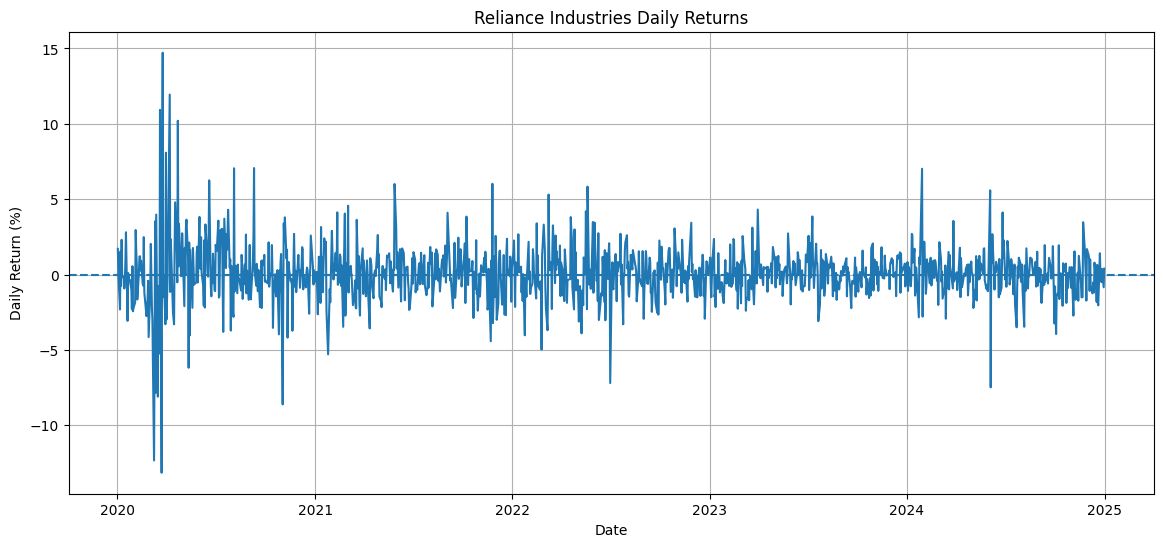

In [11]:
# ============================================
# FINSIGHT — VISUALIZE DAILY RETURNS
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot daily returns
plt.plot(
    reliance_data.index,
    reliance_data["Daily_Return"]
)

# Add a horizontal line at 0%
plt.axhline(y=0, linestyle="--")

# Add title and labels
plt.title("Reliance Industries Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [12]:
# ============================================
# FINSIGHT — CALCULATE 20-DAY VOLATILITY
# ============================================

# Calculate 20-day rolling volatility
reliance_data["Volatility_20D"] = (
    reliance_data["Daily_Return"]
    .rolling(window=20)
    .std()
)

# Confirm that the column was created
print("VOLATILITY COLUMN CREATED SUCCESSFULLY!")

print("\nCurrent columns:")
print(reliance_data.columns)

# Display some data
display(
    reliance_data[
        ["Close", "Daily_Return", "Volatility_20D"]
    ].head(25)
)

VOLATILITY COLUMN CREATED SUCCESSFULLY!

Current columns:
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'Volatility_20D'],
      dtype='object', name='Price')


Price,Close,Daily_Return,Volatility_20D
Date,,,
2020-01-01,672.216187,NaN,NaN
2020-01-02,683.660278,1.702442,NaN
2020-01-03,684.483948,0.120479,NaN
2020-01-06,668.609314,-2.319212,NaN
2020-01-07,678.895569,1.538455,NaN
2020-01-08,673.796997,-0.751010,NaN
2020-01-09,689.315430,2.303132,NaN
2020-01-10,689.159668,-0.022597,NaN
2020-01-13,687.400696,-0.255234,NaN


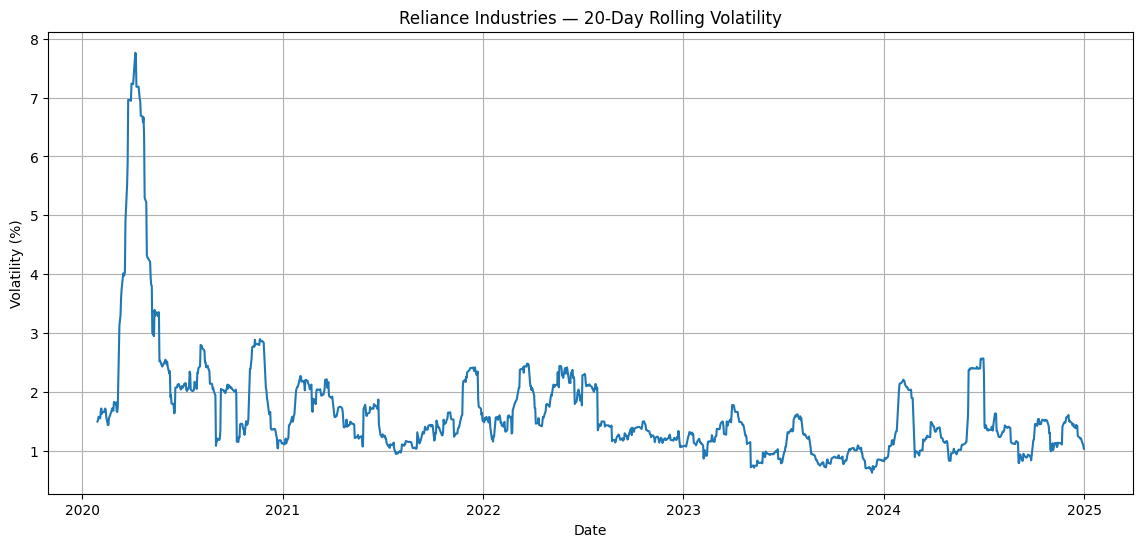

In [13]:
# ============================================
# FINSIGHT — VISUALIZE 20-DAY VOLATILITY
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    reliance_data.index,
    reliance_data["Volatility_20D"]
)

plt.title("Reliance Industries — 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.grid(True)

plt.show()

In [14]:
# ============================================
# STOCK ANALYZER — MOVING AVERAGES
# ============================================

# Calculate 20-day moving average
reliance_data["MA_20"] = (
    reliance_data["Close"]
    .rolling(window=20)
    .mean()
)

# Calculate 50-day moving average
reliance_data["MA_50"] = (
    reliance_data["Close"]
    .rolling(window=50)
    .mean()
)

# Display the first 55 rows
display(
    reliance_data[
        ["Close", "MA_20", "MA_50"]
    ].head(55)
)

Price,Close,MA_20,MA_50
Date,,,
2020-01-01,672.216187,NaN,NaN
2020-01-02,683.660278,NaN,NaN
2020-01-03,684.483948,NaN,NaN
2020-01-06,668.609314,NaN,NaN
2020-01-07,678.895569,NaN,NaN
2020-01-08,673.796997,NaN,NaN
2020-01-09,689.315430,NaN,NaN
2020-01-10,689.159668,NaN,NaN
2020-01-13,687.400696,NaN,NaN


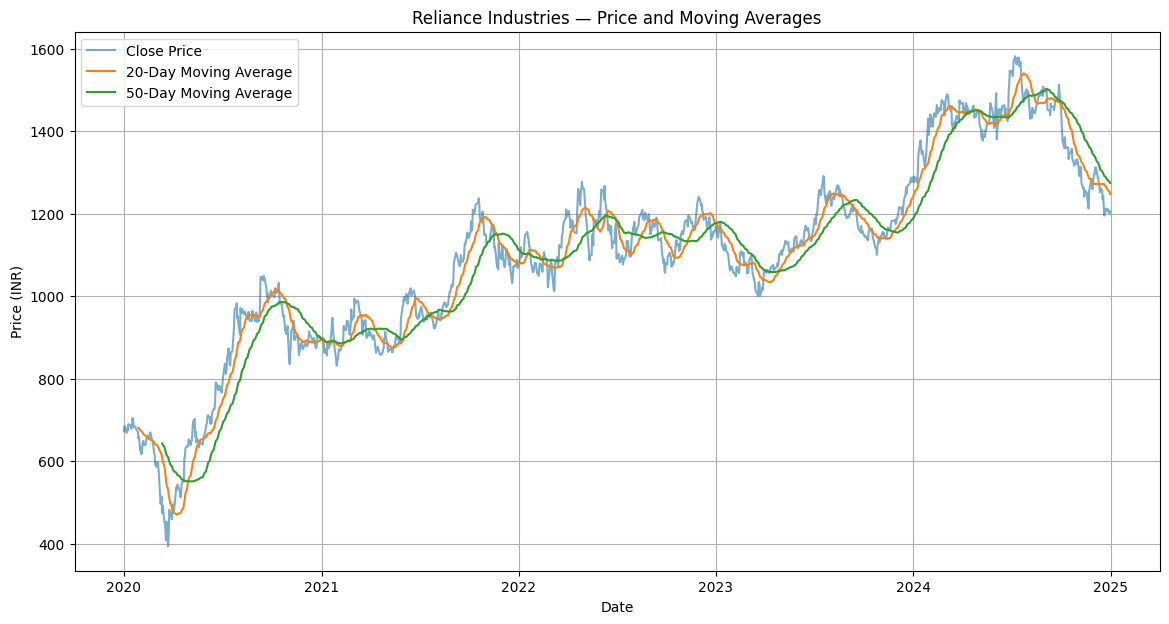

In [15]:
# ============================================
# STOCK ANALYZER — MOVING AVERAGE VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 7))

# Plot actual closing price
plt.plot(
    reliance_data.index,
    reliance_data["Close"],
    label="Close Price",
    alpha=0.6
)

# Plot 20-day moving average
plt.plot(
    reliance_data.index,
    reliance_data["MA_20"],
    label="20-Day Moving Average"
)

# Plot 50-day moving average
plt.plot(
    reliance_data.index,
    reliance_data["MA_50"],
    label="50-Day Moving Average"
)

# Add title and labels
plt.title("Reliance Industries — Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [16]:
# ============================================
# STOCK ANALYZER — RSI STEP 1
# SEPARATE GAINS AND LOSSES
# ============================================

# Calculate daily price change
reliance_data["Price_Change"] = (
    reliance_data["Close"].diff()
)

# Create Gain column
reliance_data["Gain"] = (
    reliance_data["Price_Change"].clip(lower=0)
)

# Create Loss column
reliance_data["Loss"] = (
    -reliance_data["Price_Change"].clip(upper=0)
)

# Display the result
display(
    reliance_data[
        ["Close", "Price_Change", "Gain", "Loss"]
    ].head(10)
)

Price,Close,Price_Change,Gain,Loss
Date,,,,
2020-01-01,672.216187,NaN,NaN,NaN
2020-01-02,683.660278,11.444092,11.444092,-0.000000
2020-01-03,684.483948,0.823669,0.823669,-0.000000
2020-01-06,668.609314,-15.874634,0.000000,15.874634
2020-01-07,678.895569,10.286255,10.286255,-0.000000
2020-01-08,673.796997,-5.098572,0.000000,5.098572
2020-01-09,689.315430,15.518433,15.518433,-0.000000
2020-01-10,689.159668,-0.155762,0.000000,0.155762
2020-01-13,687.400696,-1.758972,0.000000,1.758972


In [17]:
# ============================================
# STOCK ANALYZER — RSI STEP 2
# CALCULATE AVERAGE GAIN AND LOSS
# ============================================

# Calculate 14-day average gain
reliance_data["Avg_Gain_14"] = (
    reliance_data["Gain"]
    .rolling(window=14)
    .mean()
)

# Calculate 14-day average loss
reliance_data["Avg_Loss_14"] = (
    reliance_data["Loss"]
    .rolling(window=14)
    .mean()
)

# Display the result
display(
    reliance_data[
        ["Gain", "Loss", "Avg_Gain_14", "Avg_Loss_14"]
    ].head(20)
)

Price,Gain,Loss,Avg_Gain_14,Avg_Loss_14
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2020-01-02,11.444092,-0.000000,NaN,NaN
2020-01-03,0.823669,-0.000000,NaN,NaN
2020-01-06,0.000000,15.874634,NaN,NaN
2020-01-07,10.286255,-0.000000,NaN,NaN
2020-01-08,0.000000,5.098572,NaN,NaN
2020-01-09,15.518433,-0.000000,NaN,NaN
2020-01-10,0.000000,0.155762,NaN,NaN
2020-01-13,0.000000,1.758972,NaN,NaN


In [18]:
# ============================================
# STOCK ANALYZER — RSI STEP 3
# CALCULATE RS AND RSI
# ============================================

# Calculate Relative Strength (RS)
reliance_data["RS"] = (
    reliance_data["Avg_Gain_14"] /
    reliance_data["Avg_Loss_14"]
)

# Calculate RSI
reliance_data["RSI_14"] = (
    100 - (100 / (1 + reliance_data["RS"]))
)

# Display the result
display(
    reliance_data[
        ["Avg_Gain_14", "Avg_Loss_14", "RS", "RSI_14"]
    ].head(25)
)

Price,Avg_Gain_14,Avg_Loss_14,RS,RSI_14
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN
2020-01-09,NaN,NaN,NaN,NaN
2020-01-10,NaN,NaN,NaN,NaN
2020-01-13,NaN,NaN,NaN,NaN


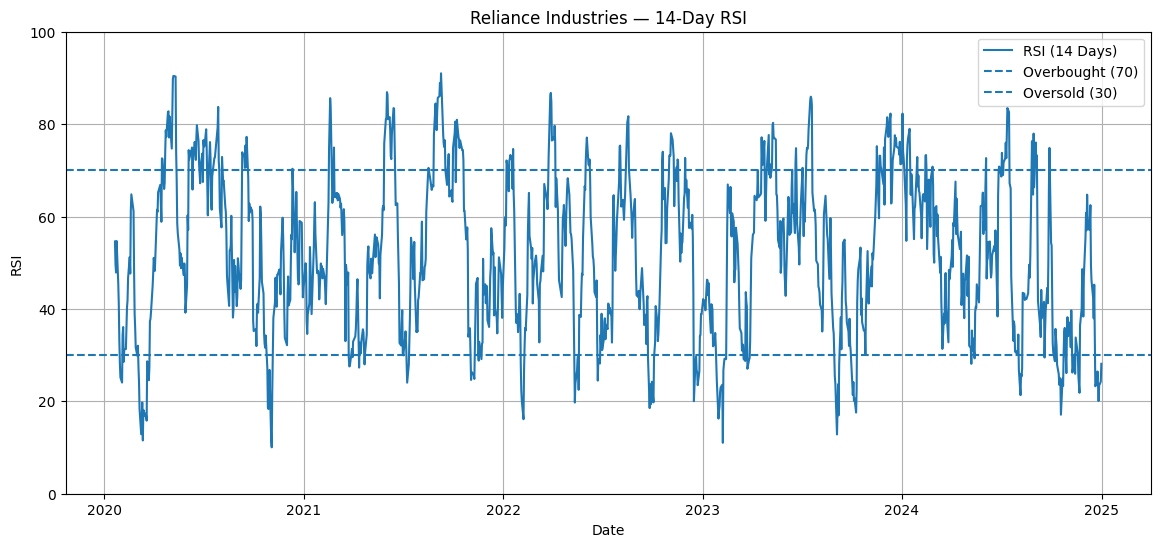

In [19]:
# ============================================
# STOCK ANALYZER — RSI VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot RSI
plt.plot(
    reliance_data.index,
    reliance_data["RSI_14"],
    label="RSI (14 Days)"
)

# Add overbought line
plt.axhline(y=70, linestyle="--", label="Overbought (70)")

# Add oversold line
plt.axhline(y=30, linestyle="--", label="Oversold (30)")

# Add title and labels
plt.title("Reliance Industries — 14-Day RSI")
plt.xlabel("Date")
plt.ylabel("RSI")

# Set RSI range
plt.ylim(0, 100)

# Add legend and grid
plt.legend()
plt.grid(True)

# Display graph
plt.show()

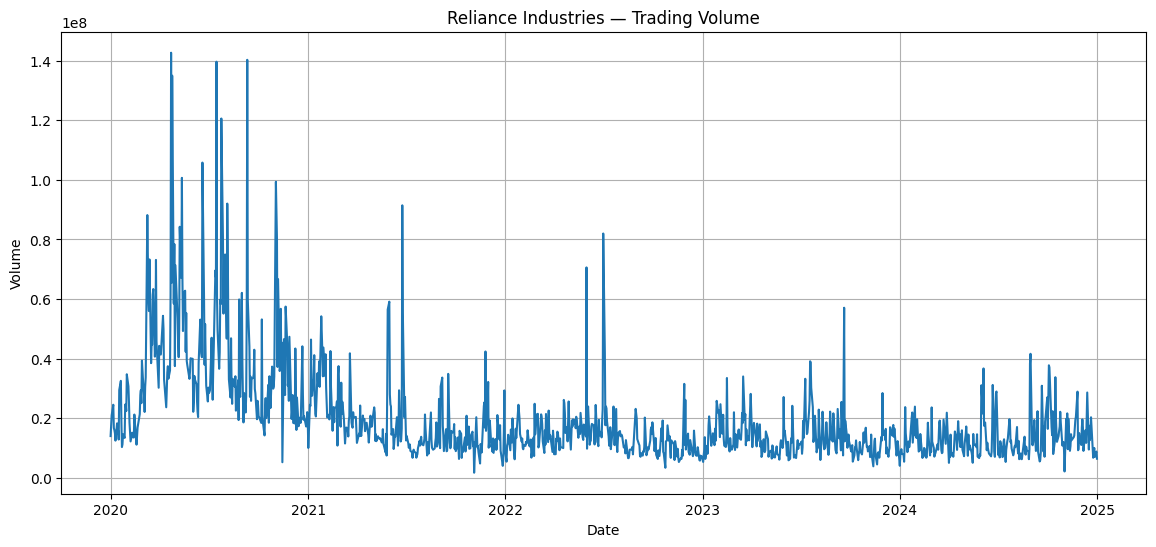

In [20]:
# ============================================
# STOCK ANALYZER — VOLUME ANALYSIS
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot trading volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume"]
)

# Add title and labels
plt.title("Reliance Industries — Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [21]:
# ============================================
# STOCK ANALYZER — VOLUME MOVING AVERAGE
# ============================================

# Calculate 20-day average trading volume
reliance_data["Volume_MA_20"] = (
    reliance_data["Volume"]
    .rolling(window=20)
    .mean()
)

# Display Volume and its moving average
display(
    reliance_data[
        ["Volume", "Volume_MA_20"]
    ].head(25)
)

Price,Volume,Volume_MA_20
Date,,
2020-01-01,14004468,NaN
2020-01-02,17710316,NaN
2020-01-03,20984698,NaN
2020-01-06,24519177,NaN
2020-01-07,16683622,NaN
2020-01-08,16047902,NaN
2020-01-09,14982742,NaN
2020-01-10,12478359,NaN
2020-01-13,18282382,NaN


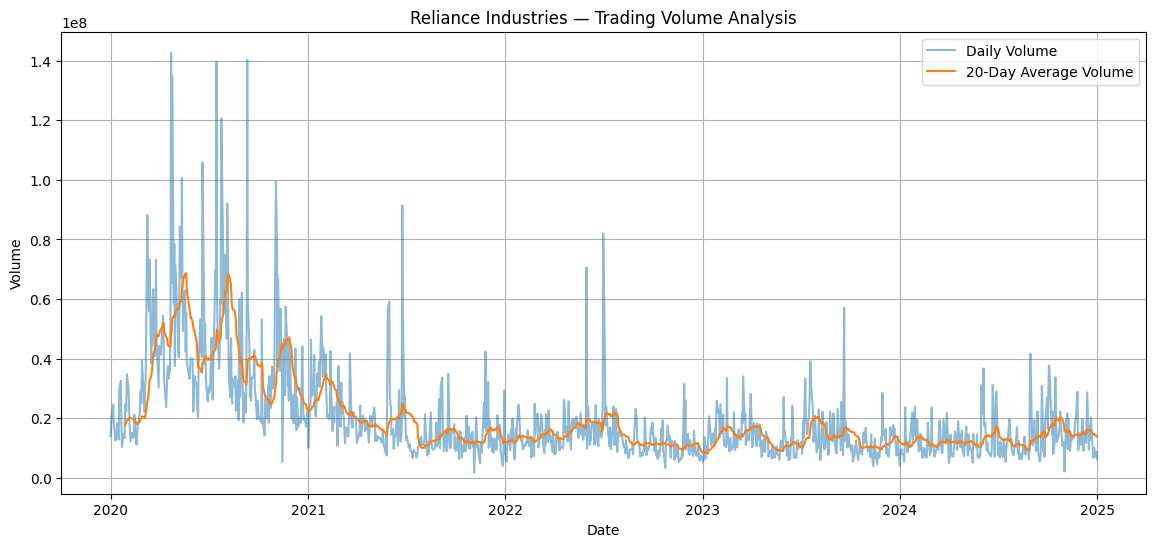

In [22]:
# ============================================
# STOCK ANALYZER — VOLUME VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot actual trading volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume"],
    label="Daily Volume",
    alpha=0.5
)

# Plot 20-day average volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume_MA_20"],
    label="20-Day Average Volume"
)

# Add title and labels
plt.title("Reliance Industries — Trading Volume Analysis")
plt.xlabel("Date")
plt.ylabel("Volume")

# Add legend and grid
plt.legend()
plt.grid(True)

# Display graph
plt.show()

In [23]:
# ============================================
# STOCK ANALYZER — VOLUME RATIO
# ============================================

# Compare today's volume with the 20-day average volume
reliance_data["Volume_Ratio"] = (
    reliance_data["Volume"] /
    reliance_data["Volume_MA_20"]
)

# Display the relevant columns
display(
    reliance_data[
        ["Volume", "Volume_MA_20", "Volume_Ratio"]
    ].head(25)
)

Price,Volume,Volume_MA_20,Volume_Ratio
Date,,,
2020-01-01,14004468,NaN,NaN
2020-01-02,17710316,NaN,NaN
2020-01-03,20984698,NaN,NaN
2020-01-06,24519177,NaN,NaN
2020-01-07,16683622,NaN,NaN
2020-01-08,16047902,NaN,NaN
2020-01-09,14982742,NaN,NaN
2020-01-10,12478359,NaN,NaN
2020-01-13,18282382,NaN,NaN


In [24]:
# ============================================
# STOCK ANALYZER — PRICE VS MOVING AVERAGE
# ============================================

# Percentage difference between current price and 20-day average
reliance_data["Price_vs_MA20"] = (
    (reliance_data["Close"] - reliance_data["MA_20"])
    / reliance_data["MA_20"]
) * 100

# Percentage difference between current price and 50-day average
reliance_data["Price_vs_MA50"] = (
    (reliance_data["Close"] - reliance_data["MA_50"])
    / reliance_data["MA_50"]
) * 100

# Display the new features
display(
    reliance_data[
        [
            "Close",
            "MA_20",
            "MA_50",
            "Price_vs_MA20",
            "Price_vs_MA50"
        ]
    ].tail(10)
)

Price,Close,MA_20,MA_50,Price_vs_MA20,Price_vs_MA50
Date,,,,,
2024-12-17,1234.637695,1271.593561,1300.387896,-2.906264,-5.056199
2024-12-18,1242.519653,1272.168597,1298.058513,-2.330583,-4.278610
2024-12-19,1219.914795,1272.537903,1294.749094,-4.135288,-5.779830
2024-12-20,1194.980225,1269.558636,1291.392085,-5.874357,-7.465731
2024-12-23,1211.834717,1266.351343,1288.442559,-4.305016,-5.945771
2024-12-24,1212.280762,1262.735071,1285.481133,-3.995637,-5.694395
2024-12-26,1206.133911,1258.935388,1282.388342,-4.194137,-5.946282
2024-12-27,1210.595459,1256.469189,1279.949902,-3.651003,-5.418528
2024-12-30,1200.333984,1252.429083,1277.106953,-4.159525,-6.011475


In [25]:
# ============================================
# STOCK ANALYZER — FEATURE CHECKPOINT
# ============================================

# Display all columns
print("ALL COLUMNS IN OUR DATASET:")
print(reliance_data.columns.tolist())

print("\n" + "=" * 60)

# Display dataset shape
print("DATASET SHAPE:")
print("Rows:", reliance_data.shape[0])
print("Columns:", reliance_data.shape[1])

print("\n" + "=" * 60)

# Display the latest 10 observations
print("LATEST 10 OBSERVATIONS:")
display(
    reliance_data.tail(10)
)

ALL COLUMNS IN OUR DATASET:
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Volatility_20D', 'MA_20', 'MA_50', 'Price_Change', 'Gain', 'Loss', 'Avg_Gain_14', 'Avg_Loss_14', 'RS', 'RSI_14', 'Volume_MA_20', 'Volume_Ratio', 'Price_vs_MA20', 'Price_vs_MA50']

DATASET SHAPE:
Rows: 1238
Columns: 20

LATEST 10 OBSERVATIONS:


Price,Close,High,Low,Open,Volume,Daily_Return,Volatility_20D,MA_20,MA_50,Price_Change,Gain,Loss,Avg_Gain_14,Avg_Loss_14,RS,RSI_14,Volume_MA_20,Volume_Ratio,Price_vs_MA20,Price_vs_MA50
Date,,,,,,,,,,,,,,,,,,,,
2024-12-17,1234.637695,1253.078416,1232.159101,1250.252843,17462791,-1.813463,1.439879,1271.593561,1300.387896,-22.803223,0.000000,22.803223,5.350228,8.742362,0.611989,37.964833,16118301.55,1.083414,-2.906264,-5.056199
2024-12-18,1242.519653,1249.162239,1230.027559,1230.027559,12670179,0.638403,1.404796,1272.168597,1298.058513,7.881958,7.881958,-0.000000,5.913225,7.156067,0.826323,45.245185,16042623.20,0.789782,-2.330583,-4.278610
2024-12-19,1219.914795,1234.241146,1218.477258,1228.391638,14244653,-1.819276,1.424959,1272.537903,1294.749094,-22.604858,0.000000,22.604858,4.397749,8.770700,0.501414,33.396104,15783163.70,0.902522,-4.135288,-5.779830
2024-12-20,1194.980225,1228.887355,1191.212712,1213.520066,20312896,-2.043960,1.249426,1269.558636,1291.392085,-24.934570,0.000000,24.934570,3.197388,10.551740,0.303020,23.255203,15775210.65,1.287647,-5.874357,-7.465731
2024-12-23,1211.834717,1216.692666,1202.812534,1204.597171,10052824,1.410441,1.226714,1266.351343,1288.442559,16.854492,16.854492,-0.000000,3.399231,10.551740,0.322149,24.365550,14831684.80,0.677794,-4.305016,-5.945771
2024-12-24,1212.280762,1222.988340,1210.545745,1211.834663,6734917,0.036807,1.209514,1262.735071,1285.481133,0.446045,0.446045,-0.000000,3.431091,9.535514,0.359822,26.460984,14706052.80,0.457969,-3.995637,-5.694395
2024-12-26,1206.133911,1217.188348,1203.853555,1213.767935,10016178,-0.507048,1.210331,1258.935388,1282.388342,-6.146851,0.000000,6.146851,2.503383,9.974574,0.250976,20.062443,14728224.40,0.680067,-4.194137,-5.946282
2024-12-27,1210.595459,1217.386785,1206.580087,1207.869004,7000397,0.369905,1.169837,1256.469189,1279.949902,4.461548,4.461548,-0.000000,2.822065,9.230992,0.305716,23.413687,14326873.65,0.488620,-3.651003,-5.418528
2024-12-30,1200.333984,1212.726960,1197.756270,1205.985254,8818766,-0.847639,1.090319,1252.429083,1277.106953,-10.261475,0.000000,10.261475,2.822065,8.802560,0.320596,24.276612,14107696.60,0.625103,-4.159525,-6.011475


In [26]:
# ============================================
# STOCK ANALYZER — MACD
# ============================================

# Calculate the 12-day exponential moving average
reliance_data["EMA_12"] = (
    reliance_data["Close"]
    .ewm(span=12, adjust=False)
    .mean()
)

# Calculate the 26-day exponential moving average
reliance_data["EMA_26"] = (
    reliance_data["Close"]
    .ewm(span=26, adjust=False)
    .mean()
)

# Calculate MACD
reliance_data["MACD"] = (
    reliance_data["EMA_12"] -
    reliance_data["EMA_26"]
)

# Display the latest observations
display(
    reliance_data[
        [
            "Close",
            "EMA_12",
            "EMA_26",
            "MACD"
        ]
    ].tail(10)
)

Price,Close,EMA_12,EMA_26,MACD
Date,,,,
2024-12-17,1234.637695,1267.097743,1279.938885,-12.841142
2024-12-18,1242.519653,1263.316499,1277.167091,-13.850592
2024-12-19,1219.914795,1256.639313,1272.926180,-16.286866
2024-12-20,1194.980225,1247.153300,1267.152405,-19.999105
2024-12-23,1211.834717,1241.719672,1263.054799,-21.335127
2024-12-24,1212.280762,1237.190609,1259.293759,-22.103150
2024-12-26,1206.133911,1232.412655,1255.355992,-22.943337
2024-12-27,1210.595459,1229.056163,1252.040397,-22.984234
2024-12-30,1200.333984,1224.637367,1248.210293,-23.572926


In [27]:
# ============================================
# STOCK ANALYZER — MACD SIGNAL LINE
# ============================================

# Calculate the 9-day EMA of the MACD line
reliance_data["MACD_Signal"] = (
    reliance_data["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)

# Calculate the MACD Histogram
reliance_data["MACD_Histogram"] = (
    reliance_data["MACD"] -
    reliance_data["MACD_Signal"]
)

# Display the latest observations
display(
    reliance_data[
        [
            "MACD",
            "MACD_Signal",
            "MACD_Histogram"
        ]
    ].tail(10)
)

Price,MACD,MACD_Signal,MACD_Histogram
Date,,,
2024-12-17,-12.841142,-10.937767,-1.903375
2024-12-18,-13.850592,-11.520332,-2.330260
2024-12-19,-16.286866,-12.473639,-3.813228
2024-12-20,-19.999105,-13.978732,-6.020373
2024-12-23,-21.335127,-15.450011,-5.885116
2024-12-24,-22.103150,-16.780639,-5.322511
2024-12-26,-22.943337,-18.013179,-4.930159
2024-12-27,-22.984234,-19.007390,-3.976844
2024-12-30,-23.572926,-19.920497,-3.652429


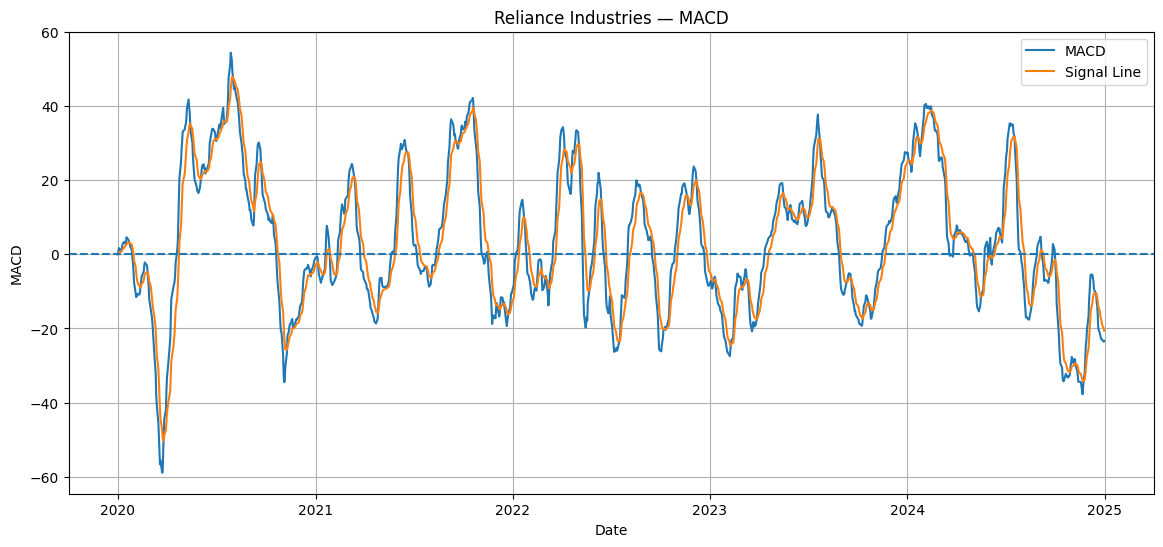

In [29]:
# ============================================
# STOCK ANALYZER — MACD VISUALIZATION
# ============================================

plt.figure(figsize=(14, 6))

# Plot MACD
plt.plot(
    reliance_data.index,
    reliance_data["MACD"],
    label="MACD"
)

# Plot Signal Line
plt.plot(
    reliance_data.index,
    reliance_data["MACD_Signal"],
    label="Signal Line"
)

# Add zero reference line
plt.axhline(
    y=0,
    linestyle="--"
)

# Title and labels
plt.title("Reliance Industries — MACD")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
# ============================================
# STOCK ANALYZER — OVERALL RETURN
# ============================================

# Get the first and last closing prices
starting_price = reliance_data["Close"].iloc[0]
ending_price = reliance_data["Close"].iloc[-1]

# Calculate total price return
total_return = (
    (ending_price - starting_price)
    / starting_price
) * 100

# Display the result
print("RELIANCE OVERALL PERFORMANCE")
print("=" * 40)

print("Starting Price:", round(float(starting_price), 2))
print("Ending Price:", round(float(ending_price), 2))
print("Total Return:", round(float(total_return), 2), "%")

RELIANCE OVERALL PERFORMANCE
Starting Price: 672.22
Ending Price: 1205.04
Total Return: 79.26 %


In [31]:
# ============================================
# STOCK ANALYZER — MAXIMUM DRAWDOWN
# ============================================

# Calculate the highest closing price reached
# up to each point in time
reliance_data["Running_Peak"] = (
    reliance_data["Close"].cummax()
)

# Calculate drawdown from the running peak
reliance_data["Drawdown"] = (
    (reliance_data["Close"] - reliance_data["Running_Peak"])
    / reliance_data["Running_Peak"]
) * 100

# Find the worst drawdown
maximum_drawdown = reliance_data["Drawdown"].min()

print("RELIANCE MAXIMUM DRAWDOWN")
print("=" * 40)

print(
    "Maximum Drawdown:",
    round(float(maximum_drawdown), 2),
    "%"
)

RELIANCE MAXIMUM DRAWDOWN
Maximum Drawdown: -44.08 %


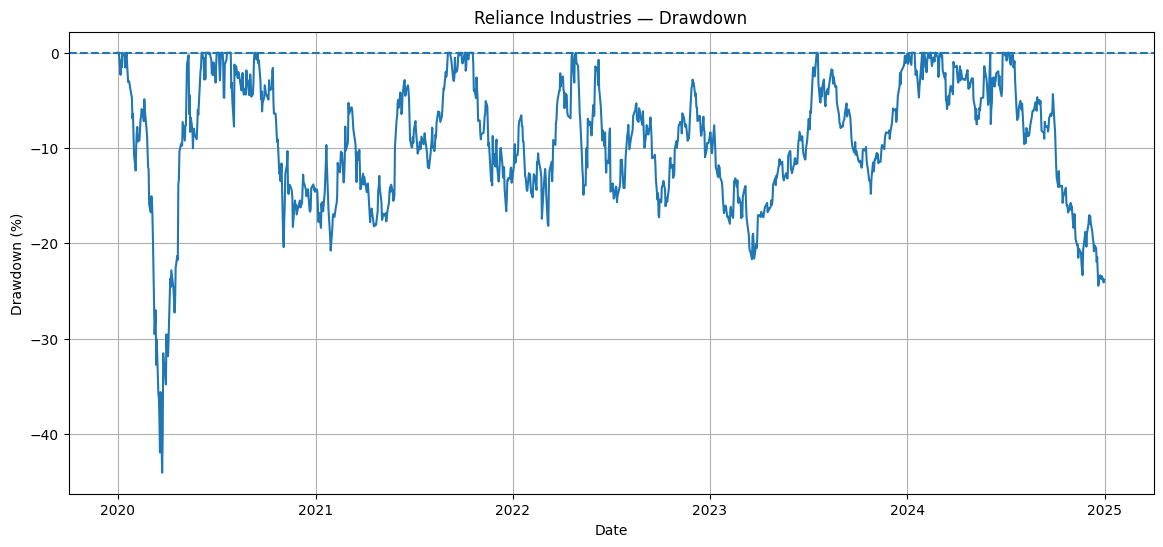

In [32]:
# ============================================
# STOCK ANALYZER — DRAWDOWN VISUALIZATION
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    reliance_data.index,
    reliance_data["Drawdown"]
)

# Add zero reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Reliance Industries — Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.grid(True)

plt.show()

In [33]:
# ============================================
# STOCK ANALYZER — RELIANCE SUMMARY
# ============================================

# Get the latest row of our dataset
latest = reliance_data.iloc[-1]

# Create a summary dictionary
reliance_summary = {
    "Current Price": float(latest["Close"]),
    "Daily Return (%)": float(latest["Daily_Return"]),
    "20-Day Volatility (%)": float(latest["Volatility_20D"]),
    "MA_20": float(latest["MA_20"]),
    "MA_50": float(latest["MA_50"]),
    "RSI_14": float(latest["RSI_14"]),
    "Volume Ratio": float(latest["Volume_Ratio"]),
    "MACD": float(latest["MACD"]),
    "Overall Return (%)": float(total_return),
    "Maximum Drawdown (%)": float(maximum_drawdown)
}

# Convert dictionary into a table
summary_df = pd.DataFrame(
    reliance_summary.items(),
    columns=["Metric", "Value"]
)

# Display the summary
print("RELIANCE INDUSTRIES — STOCK ANALYSIS SUMMARY")
print("=" * 55)

display(summary_df)

RELIANCE INDUSTRIES — STOCK ANALYSIS SUMMARY


,Metric,Value
0,Current Price,1205.043213
1,Daily Return (%),0.392327
2,20-Day Volatility (%),1.035947
3,MA_20,1247.784186
4,MA_50,1274.311592
5,RSI_14,28.121063
6,Volume Ratio,0.461597
7,MACD,-23.389850
8,Overall Return (%),79.264236
9,Maximum Drawdown (%),-44.082857


In [34]:
# ============================================
# STOCK ANALYZER — BASIC INTERPRETATION
# ============================================

# Current price vs moving averages
current_price = latest["Close"]
ma20 = latest["MA_20"]
ma50 = latest["MA_50"]
rsi = latest["RSI_14"]
volatility = latest["Volatility_20D"]

print("RELIANCE — BASIC MARKET INTERPRETATION")
print("=" * 55)

# Trend interpretation
if current_price > ma20 and ma20 > ma50:
    print("Trend: Stronger recent upward trend")
elif current_price < ma20 and ma20 < ma50:
    print("Trend: Stronger recent downward trend")
else:
    print("Trend: Mixed / transitional")

# RSI interpretation
if rsi > 70:
    print("Momentum: Strong upward momentum / potentially overbought")
elif rsi < 30:
    print("Momentum: Strong downward momentum / potentially oversold")
else:
    print("Momentum: Relatively neutral")

# Volatility interpretation
if volatility > 3:
    print("Volatility: High")
elif volatility > 1.5:
    print("Volatility: Moderate")
else:
    print("Volatility: Relatively low")

RELIANCE — BASIC MARKET INTERPRETATION
Trend: Stronger recent downward trend
Momentum: Strong downward momentum / potentially oversold
Volatility: Relatively low


In [35]:
# ============================================
# STOCK ANALYZER — COMPANY INFORMATION
# ============================================

# Create a Yahoo Finance ticker object
reliance = yf.Ticker("RELIANCE.NS")

# Get company information
company_info = reliance.info

# Display some important information
print("RELIANCE INDUSTRIES — COMPANY INFORMATION")
print("=" * 55)

print("Company Name:", company_info.get("longName"))
print("Sector:", company_info.get("sector"))
print("Industry:", company_info.get("industry"))
print("Market Cap:", company_info.get("marketCap"))
print("Currency:", company_info.get("currency"))

RELIANCE INDUSTRIES — COMPANY INFORMATION
Company Name: Reliance Industries Limited
Sector: Energy
Industry: Oil & Gas Refining & Marketing
Market Cap: None
Currency: INR


In [36]:
# ============================================
# STOCK ANALYZER — INSPECT COMPANY DATA
# ============================================

# Display all available information fields
print("AVAILABLE COMPANY INFORMATION FIELDS:")
print("=" * 55)

for key in sorted(company_info.keys()):
    print(key)

AVAILABLE COMPANY INFORMATION FIELDS:
52WeekChange
SandP52WeekChange
address1
address2
allTimeHigh
allTimeLow
ask
averageAnalystRating
averageDailyVolume10Day
averageDailyVolume3Month
averageVolume
averageVolume10days
beta
bid
bookValue
city
companyOfficers
compensationAsOfEpochDate
corporateActions
country
cryptoTradeable
currency
currentPrice
customPriceAlertConfidence
dayHigh
dayLow
debtToEquity
dividendRate
dividendYield
earningsGrowth
earningsQuarterlyGrowth
earningsTimestampEnd
earningsTimestampStart
ebitda
ebitdaMargins
enterpriseToEbitda
enterpriseToRevenue
enterpriseValue
epsCurrentYear
epsForward
epsTrailingTwelveMonths
esgPopulated
exDividendDate
exchange
exchangeDataDelayedBy
exchangeTimezoneName
exchangeTimezoneShortName
executiveTeam
fax
fiftyDayAverage
fiftyDayAverageChange
fiftyDayAverageChangePercent
fiftyTwoWeekChangePercent
fiftyTwoWeekHigh
fiftyTwoWeekHighChange
fiftyTwoWeekHighChangePercent
fiftyTwoWeekLow
fiftyTwoWeekLowChange
fiftyTwoWeekLowChangePercent
fiftyTwo

In [37]:
# ============================================
# STOCK ANALYZER — KEY FUNDAMENTAL METRICS
# ============================================

# Extract selected fundamental metrics safely
fundamentals = {
    "Market Cap": company_info.get("marketCap"),
    "P/E Ratio": company_info.get("trailingPE"),
    "Forward P/E": company_info.get("forwardPE"),
    "Price to Book": company_info.get("priceToBook"),
    "Profit Margin": company_info.get("profitMargins"),
    "Operating Margin": company_info.get("operatingMargins"),
    "Return on Equity": company_info.get("returnOnEquity"),
    "Return on Assets": company_info.get("returnOnAssets"),
    "Revenue Growth": company_info.get("revenueGrowth"),
    "Earnings Growth": company_info.get("earningsGrowth"),
    "Dividend Yield": company_info.get("dividendYield")
}

# Display the metrics
fundamentals_df = pd.DataFrame(
    fundamentals.items(),
    columns=["Metric", "Value"]
)

print("RELIANCE — KEY FUNDAMENTAL METRICS")
print("=" * 55)

display(fundamentals_df)

RELIANCE — KEY FUNDAMENTAL METRICS


,Metric,Value
0,Market Cap,NaN
1,P/E Ratio,22.780796
2,Forward P/E,17.614760
3,Price to Book,1.882358
4,Profit Margin,0.066150
5,Operating Margin,0.123310
6,Return on Equity,NaN
7,Return on Assets,NaN
8,Revenue Growth,0.297000
9,Earnings Growth,-0.224000


In [38]:
# ============================================
# STOCK ANALYZER — CLEAN FUNDAMENTAL SUMMARY
# ============================================

# Convert decimal-based metrics into percentages
percentage_metrics = [
    "Profit Margin",
    "Operating Margin",
    "Return on Equity",
    "Return on Assets",
    "Revenue Growth",
    "Earnings Growth",
    "Dividend Yield"
]

fundamentals_clean = fundamentals.copy()

for metric in percentage_metrics:
    value = fundamentals_clean[metric]

    if value is not None and pd.notna(value):
        fundamentals_clean[metric] = value * 100

# Create a clean table
fundamentals_clean_df = pd.DataFrame(
    fundamentals_clean.items(),
    columns=["Metric", "Value"]
)

print("RELIANCE — CLEAN FUNDAMENTAL SUMMARY")
print("=" * 55)

display(fundamentals_clean_df)

RELIANCE — CLEAN FUNDAMENTAL SUMMARY


,Metric,Value
0,Market Cap,NaN
1,P/E Ratio,22.780796
2,Forward P/E,17.614760
3,Price to Book,1.882358
4,Profit Margin,6.615000
5,Operating Margin,12.331000
6,Return on Equity,NaN
7,Return on Assets,NaN
8,Revenue Growth,29.700000
9,Earnings Growth,-22.400000


In [39]:
# ============================================
# STOCK ANALYZER — INCOME STATEMENT
# ============================================

# Download Reliance's annual financial statements
income_statement = reliance.financials

# Display the available financial statement data
print("RELIANCE — INCOME STATEMENT")
print("=" * 60)

display(income_statement)

RELIANCE — INCOME STATEMENT


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Tax Effect Of Unusual Items,6.330710e+09,3.339140e+09,4.065480e+09,-3.185730e+09,NaN
Tax Rate For Calcs,2.237000e-01,2.380000e-01,2.455000e-01,2.185000e-01,NaN
Normalized EBITDA,2.020760e+12,1.798710e+12,1.752880e+12,1.547650e+12,NaN
Total Unusual Items,2.830000e+10,1.403000e+10,1.656000e+10,-1.458000e+10,NaN
Total Unusual Items Excluding Goodwill,2.830000e+10,1.403000e+10,1.656000e+10,-1.458000e+10,NaN
Net Income From Continuing Operation Net Minority Interest,8.077500e+11,6.964800e+11,6.962100e+11,6.628400e+11,NaN
Reconciled Depreciation,5.768800e+11,5.313600e+11,5.083200e+11,4.030300e+11,NaN
Reconciled Cost Of Revenue,7.868240e+12,7.226870e+12,6.745990e+12,6.718980e+12,NaN
EBITDA,2.049060e+12,1.812740e+12,1.769440e+12,1.533070e+12,NaN
EBIT,1.472180e+12,1.281380e+12,1.261120e+12,1.130040e+12,NaN


In [40]:
# ============================================
# STOCK ANALYZER — KEY INCOME STATEMENT ITEMS
# ============================================

# Financial statement rows we want to inspect
income_items = [
    "Total Revenue",
    "Operating Income",
    "Net Income",
    "Gross Profit",
    "EBIT",
    "EBITDA"
]

# Keep only rows that actually exist in the dataset
available_items = [
    item for item in income_items
    if item in income_statement.index
]

# Extract available rows
income_summary = income_statement.loc[
    available_items
]

print("KEY INCOME STATEMENT ITEMS")
print("=" * 60)

display(income_summary)

KEY INCOME STATEMENT ITEMS


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Total Revenue,1.057219e+13,9.646930e+12,9.010640e+12,8.778350e+12,NaN
Operating Income,1.213770e+12,1.124620e+12,1.116660e+12,1.020150e+12,NaN
Net Income,8.077500e+11,6.964800e+11,6.962100e+11,6.670200e+11,NaN
Gross Profit,2.703950e+12,2.420060e+12,2.264650e+12,2.059370e+12,NaN
EBIT,1.472180e+12,1.281380e+12,1.261120e+12,1.130040e+12,NaN
EBITDA,2.049060e+12,1.812740e+12,1.769440e+12,1.533070e+12,NaN


In [42]:
# ============================================
# STOCK ANALYZER — BALANCE SHEET
# ============================================

# Download Reliance's annual balance sheet
balance_sheet = reliance.balance_sheet

print("RELIANCE — BALANCE SHEET")
print("=" * 60)

display(balance_sheet)

RELIANCE — BALANCE SHEET


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Ordinary Shares Number,1.353247e+10,1.353287e+10,1.353222e+10,1.353219e+10,NaN
Share Issued,1.353247e+10,1.353287e+10,1.353222e+10,1.353219e+10,NaN
Net Debt,2.370940e+12,2.468850e+12,2.310820e+12,2.798100e+12,NaN
Total Debt,3.980000e+12,3.695750e+12,3.461420e+12,3.343920e+12,NaN
Tangible Book Value,4.849230e+12,4.342610e+12,4.331070e+12,3.850770e+12,NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,2.772120e+12,2.387920e+12,2.113100e+12,1.612330e+12,NaN
Other Short Term Investments,1.398850e+12,1.381470e+12,1.177700e+12,1.270770e+12,NaN
Cash And Cash Equivalents,1.373270e+12,1.006450e+12,9.354000e+11,3.415600e+11,NaN
Cash Equivalents,3.875000e+10,5.416000e+11,1.952800e+11,3.018400e+11,NaN


In [43]:
# ============================================
# STOCK ANALYZER — KEY BALANCE SHEET ITEMS
# ============================================

# Important balance-sheet metrics to inspect
balance_items = [
    "Total Assets",
    "Total Liabilities Net Minority Interest",
    "Stockholders Equity",
    "Cash Cash Equivalents And Short Term Investments",
    "Total Debt",
    "Net Debt",
    "Inventory",
    "Receivables"
]

# Keep only metrics available for this company
available_balance_items = [
    item for item in balance_items
    if item in balance_sheet.index
]

# Extract available metrics
balance_summary = balance_sheet.loc[
    available_balance_items
]

print("KEY BALANCE SHEET ITEMS")
print("=" * 60)

display(balance_summary)

KEY BALANCE SHEET ITEMS


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Total Assets,2.178140e+13,1.950121e+13,1.755986e+13,1.607431e+13,NaN
Total Liabilities Net Minority Interest,1.092274e+13,9.404930e+12,8.301980e+12,7.785500e+12,NaN
Stockholders Equity,9.040300e+12,8.432000e+12,7.934810e+12,7.158720e+12,NaN
Cash Cash Equivalents And Short Term Investments,2.772120e+12,2.387920e+12,2.113100e+12,1.612330e+12,NaN
Total Debt,3.980000e+12,3.695750e+12,3.461420e+12,3.343920e+12,NaN
Net Debt,2.370940e+12,2.468850e+12,2.310820e+12,2.798100e+12,NaN
Inventory,1.669410e+12,1.460620e+12,1.527700e+12,1.400080e+12,NaN


In [44]:
# ============================================
# STOCK ANALYZER — CASH VS DEBT
# ============================================

cash = company_info.get("totalCash")
debt = company_info.get("totalDebt")

print("RELIANCE — CASH VS DEBT")
print("=" * 50)

print("Total Cash:", cash)
print("Total Debt:", debt)

if cash is not None and debt is not None:
    net_debt = debt - cash

    print("Net Debt:", net_debt)

    if net_debt < 0:
        print("Financial position: Cash exceeds reported debt")
    elif net_debt > 0:
        print("Financial position: Reported debt exceeds cash")
    else:
        print("Financial position: Cash and debt are approximately equal")
else:
    print("Cash or debt data is unavailable.")

RELIANCE — CASH VS DEBT
Total Cash: 2581470117888
Total Debt: 3979999969280
Net Debt: 1398529851392
Financial position: Reported debt exceeds cash


In [45]:
# ============================================
# STOCK ANALYZER — PROFIT MARGIN
# ============================================

# Check whether the required rows exist
if (
    "Total Revenue" in income_statement.index
    and "Net Income" in income_statement.index
):

    # Get the annual revenue
    revenue = income_statement.loc["Total Revenue"]

    # Get the annual net income
    net_income = income_statement.loc["Net Income"]

    # Calculate profit margin
    profit_margin = (
        net_income / revenue
    ) * 100

    print("RELIANCE — PROFIT MARGIN")
    print("=" * 55)

    display(
        pd.DataFrame({
            "Revenue": revenue,
            "Net Income": net_income,
            "Profit Margin (%)": profit_margin
        })
    )

else:
    print("Required income-statement data is unavailable.")

RELIANCE — PROFIT MARGIN


,Revenue,Net Income,Profit Margin (%)
2026-03-31,1.057219e+13,8.077500e+11,7.640328
2025-03-31,9.646930e+12,6.964800e+11,7.219706
2024-03-31,9.010640e+12,6.962100e+11,7.726532
2023-03-31,8.778350e+12,6.670200e+11,7.598467
2022-03-31,NaN,NaN,NaN


In [46]:
# ============================================
# STOCK ANALYZER — REVENUE GROWTH
# ============================================

if "Total Revenue" in income_statement.index:

    # Get annual revenue
    revenue = income_statement.loc["Total Revenue"]

    # Calculate year-over-year growth
    revenue_growth = (
        revenue.pct_change(periods=-1) * 100
    )

    print("RELIANCE — REVENUE GROWTH")
    print("=" * 55)

    display(
        pd.DataFrame({
            "Revenue": revenue,
            "Revenue Growth (%)": revenue_growth
        })
    )

else:
    print("Revenue data is unavailable.")

RELIANCE — REVENUE GROWTH


/tmp/ipykernel_2391/2286858903.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  revenue.pct_change(periods=-1) * 100


,Revenue,Revenue Growth (%)
2026-03-31,1.057219e+13,9.591238
2025-03-31,9.646930e+12,7.061541
2024-03-31,9.010640e+12,2.646169
2023-03-31,8.778350e+12,0.000000
2022-03-31,NaN,NaN


In [47]:
# ============================================
# STOCK ANALYZER — RETURN ON EQUITY
# ============================================

# Check for required financial data
if (
    "Net Income" in income_statement.index
    and "Stockholders Equity" in balance_sheet.index
):

    net_income = income_statement.loc["Net Income"]

    equity = balance_sheet.loc["Stockholders Equity"]

    # Calculate ROE
    roe = (
        net_income / equity
    ) * 100

    print("RELIANCE — RETURN ON EQUITY")
    print("=" * 55)

    display(
        pd.DataFrame({
            "Net Income": net_income,
            "Equity": equity,
            "ROE (%)": roe
        })
    )

else:
    print("Required data for ROE is unavailable.")

RELIANCE — RETURN ON EQUITY


,Net Income,Equity,ROE (%)
2026-03-31,8.077500e+11,9.040300e+12,8.934991
2025-03-31,6.964800e+11,8.432000e+12,8.259962
2024-03-31,6.962100e+11,7.934810e+12,8.774123
2023-03-31,6.670200e+11,7.158720e+12,9.317588
2022-03-31,NaN,NaN,NaN


In [48]:
# ============================================
# STOCK ANALYZER — DEBT TO EQUITY
# ============================================

# Check whether the required balance-sheet rows exist
if (
    "Total Debt" in balance_sheet.index
    and "Stockholders Equity" in balance_sheet.index
):

    # Get total debt
    total_debt = balance_sheet.loc["Total Debt"]

    # Get shareholders' equity
    equity = balance_sheet.loc["Stockholders Equity"]

    # Calculate Debt-to-Equity ratio
    debt_to_equity = (
        total_debt / equity
    )

    print("RELIANCE — DEBT TO EQUITY")
    print("=" * 55)

    display(
        pd.DataFrame({
            "Total Debt": total_debt,
            "Equity": equity,
            "Debt-to-Equity": debt_to_equity
        })
    )

else:
    print("Required data for Debt-to-Equity is unavailable.")

RELIANCE — DEBT TO EQUITY


,Total Debt,Equity,Debt-to-Equity
2026-03-31,3.980000e+12,9.040300e+12,0.440251
2025-03-31,3.695750e+12,8.432000e+12,0.438301
2024-03-31,3.461420e+12,7.934810e+12,0.436232
2023-03-31,3.343920e+12,7.158720e+12,0.467111
2022-03-31,NaN,NaN,NaN


In [49]:
# ============================================
# STOCK ANALYZER — CASH FLOW STATEMENT
# ============================================

# Download annual cash-flow data
cash_flow = reliance.cashflow

print("RELIANCE — CASH FLOW STATEMENT")
print("=" * 60)

display(cash_flow)

RELIANCE — CASH FLOW STATEMENT


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Free Cash Flow,6.919700e+11,3.873600e+11,5.905000e+10,-2.595600e+11,NaN
Repayment Of Debt,-3.088100e+11,-3.175500e+11,-3.505500e+11,-2.905900e+11,NaN
Issuance Of Debt,3.887100e+11,2.637800e+11,6.961000e+11,3.593600e+11,NaN
Issuance Of Capital Stock,0.000000e+00,2.200000e+08,7.000000e+07,4.000000e+08,NaN
Capital Expenditure,-1.229160e+12,-1.399670e+12,-1.528830e+12,-1.409880e+12,NaN
End Cash Position,1.459770e+12,1.065020e+12,9.722500e+11,6.866400e+11,NaN
Other Cash Adjustment Outside Changein Cash,NaN,NaN,7.200000e+09,-1.766000e+10,9.410000e+09
Beginning Cash Position,1.065020e+12,9.722500e+11,6.866400e+11,3.617800e+11,NaN
Changes In Cash,3.947500e+11,9.277000e+10,2.856100e+11,3.425200e+11,NaN
Financing Cash Flow,-5.154900e+11,-3.189100e+11,-1.664600e+11,1.045500e+11,NaN


In [50]:
# ============================================
# STOCK ANALYZER — KEY CASH FLOW ITEMS
# ============================================

cash_flow_items = [
    "Operating Cash Flow",
    "Free Cash Flow",
    "Capital Expenditure",
    "Investing Cash Flow",
    "Financing Cash Flow"
]

# Keep only rows available in the dataset
available_cash_flow_items = [
    item for item in cash_flow_items
    if item in cash_flow.index
]

cash_flow_summary = cash_flow.loc[
    available_cash_flow_items
]

print("KEY CASH FLOW ITEMS")
print("=" * 60)

display(cash_flow_summary)

KEY CASH FLOW ITEMS


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Operating Cash Flow,1.921130e+12,1.787030e+12,1.587880e+12,1.150320e+12,NaN
Free Cash Flow,6.919700e+11,3.873600e+11,5.905000e+10,-2.595600e+11,NaN
Capital Expenditure,-1.229160e+12,-1.399670e+12,-1.528830e+12,-1.409880e+12,NaN
Investing Cash Flow,-1.010890e+12,-1.375350e+12,-1.135810e+12,-9.123500e+11,NaN
Financing Cash Flow,-5.154900e+11,-3.189100e+11,-1.664600e+11,1.045500e+11,NaN


In [51]:
# ============================================
# STOCK ANALYZER — FUNDAMENTAL ANALYSIS SUMMARY
# ============================================

# Create a dictionary for our fundamental metrics
fundamental_summary = {
    "Market Cap": company_info.get("marketCap"),
    "P/E Ratio": company_info.get("trailingPE"),
    "Price to Book": company_info.get("priceToBook"),
    "Profit Margin (%)": company_info.get("profitMargins"),
    "Operating Margin (%)": company_info.get("operatingMargins"),
    "ROE (%)": company_info.get("returnOnEquity"),
    "ROA (%)": company_info.get("returnOnAssets"),
    "Revenue Growth (%)": company_info.get("revenueGrowth"),
    "Earnings Growth (%)": company_info.get("earningsGrowth"),
    "Total Debt": company_info.get("totalDebt"),
    "Total Cash": company_info.get("totalCash")
}

# Convert decimal percentages into percentage values
for metric in [
    "Profit Margin (%)",
    "Operating Margin (%)",
    "ROE (%)",
    "ROA (%)",
    "Revenue Growth (%)",
    "Earnings Growth (%)"
]:
    value = fundamental_summary[metric]

    if value is not None and pd.notna(value):
        fundamental_summary[metric] = value * 100

# Convert to a DataFrame
fundamental_summary_df = pd.DataFrame(
    fundamental_summary.items(),
    columns=["Metric", "Value"]
)

# Display the summary
print("RELIANCE INDUSTRIES — FUNDAMENTAL ANALYSIS")
print("=" * 60)

display(fundamental_summary_df)

RELIANCE INDUSTRIES — FUNDAMENTAL ANALYSIS


,Metric,Value
0,Market Cap,NaN
1,P/E Ratio,2.278080e+01
2,Price to Book,1.882358e+00
3,Profit Margin (%),6.615000e+00
4,Operating Margin (%),1.233100e+01
5,ROE (%),NaN
6,ROA (%),NaN
7,Revenue Growth (%),2.970000e+01
8,Earnings Growth (%),-2.240000e+01
9,Total Debt,3.980000e+12


In [54]:
# ============================================
# STOCK ANALYZER — OUR FUNDAMENTAL RATIOS
# ============================================

# --- Profit Margin ---
if (
    "Total Revenue" in income_statement.index
    and "Net Income" in income_statement.index
):

    revenue = income_statement.loc["Total Revenue"]
    net_income = income_statement.loc["Net Income"]

    calculated_profit_margin = (
        net_income / revenue
    ) * 100

else:
    calculated_profit_margin = None


# --- Debt to Equity ---
if (
    "Total Debt" in balance_sheet.index
    and "Stockholders Equity" in balance_sheet.index
):

    total_debt = balance_sheet.loc["Total Debt"]
    equity = balance_sheet.loc["Stockholders Equity"]

    calculated_de = total_debt / equity

else:
    calculated_de = None


print("RELIANCE — OUR CALCULATED RATIOS")
print("=" * 60)

print("\nProfit Margin:")
display(calculated_profit_margin)

print("\nDebt-to-Equity:")
display(calculated_de)

RELIANCE — OUR CALCULATED RATIOS

Profit Margin:


,0
2026-03-31,7.640328
2025-03-31,7.219706
2024-03-31,7.726532
2023-03-31,7.598467
2022-03-31,NaN



Debt-to-Equity:


,0
2026-03-31,0.440251
2025-03-31,0.438301
2024-03-31,0.436232
2023-03-31,0.467111
2022-03-31,NaN


In [55]:
# ============================================
# STOCK ANALYZER — COMBINED COMPANY PROFILE
# ============================================

# Get the latest market/technical observation
latest = reliance_data.iloc[-1]

# Create a combined company profile
reliance_profile = {
    # -----------------------------
    # COMPANY INFORMATION
    # -----------------------------
    "Company": company_info.get("longName"),
    "Sector": company_info.get("sector"),
    "Industry": company_info.get("industry"),

    # -----------------------------
    # MARKET DATA
    # -----------------------------
    "Current Price": float(latest["Close"]),
    "Daily Return (%)": float(latest["Daily_Return"]),
    "Volatility_20D (%)": float(latest["Volatility_20D"]),
    "MA_20": float(latest["MA_20"]),
    "MA_50": float(latest["MA_50"]),
    "RSI_14": float(latest["RSI_14"]),
    "MACD": float(latest["MACD"]),
    "Volume_Ratio": float(latest["Volume_Ratio"]),
    "Price_vs_MA20 (%)": float(latest["Price_vs_MA20"]),
    "Price_vs_MA50 (%)": float(latest["Price_vs_MA50"]),

    # -----------------------------
    # PERFORMANCE
    # -----------------------------
    "Overall Return (%)": float(total_return),
    "Maximum Drawdown (%)": float(maximum_drawdown),

    # -----------------------------
    # FUNDAMENTALS
    # -----------------------------
    "Market Cap": company_info.get("marketCap"),
    "P/E Ratio": company_info.get("trailingPE"),
    "Price to Book": company_info.get("priceToBook"),
    "Profit Margin": company_info.get("profitMargins"),
    "ROE": company_info.get("returnOnEquity"),
    "ROA": company_info.get("returnOnAssets"),
    "Revenue Growth": company_info.get("revenueGrowth"),
    "Earnings Growth": company_info.get("earningsGrowth"),
    "Total Debt": company_info.get("totalDebt"),
    "Total Cash": company_info.get("totalCash")
}

# Convert the dictionary into a table
reliance_profile_df = pd.DataFrame(
    reliance_profile.items(),
    columns=["Metric", "Value"]
)

print("RELIANCE INDUSTRIES — COMBINED COMPANY PROFILE")
print("=" * 65)

display(reliance_profile_df)

RELIANCE INDUSTRIES — COMBINED COMPANY PROFILE


,Metric,Value
0,Company,Reliance Industries Limited
1,Sector,Energy
2,Industry,Oil & Gas Refining & Marketing
3,Current Price,1205.043213
4,Daily Return (%),0.392327
5,Volatility_20D (%),1.035947
6,MA_20,1247.784186
7,MA_50,1274.311592
8,RSI_14,28.121063
9,MACD,-23.38985


In [56]:
# ============================================
# STOCK ANALYZER — SAVE COMPANY PROFILE
# ============================================

profile_file = "reliance_company_profile.csv"

reliance_profile_df.to_csv(
    profile_file,
    index=False
)

print("Company profile saved successfully!")
print("File:", profile_file)

Company profile saved successfully!
File: reliance_company_profile.csv


In [57]:
# ============================================
# STOCK ANALYZER — FIRST FUNCTION
# ============================================

def greet_company(company_name):
    print("Analyzing:", company_name)


greet_company("Reliance Industries")
greet_company("Tata Consultancy Services")

Analyzing: Reliance Industries
Analyzing: Tata Consultancy Services


In [58]:
# ============================================
# STOCK ANALYZER — COMPANY DATA FUNCTION
# ============================================

def get_stock_data(ticker):
    """
    Download historical stock data for a company.
    """

    data = yf.download(
        ticker,
        start="2020-01-01",
        end="2025-01-01"
    )

    return data


# Test the function
test_data = get_stock_data("TCS.NS")

print("TCS data downloaded!")
display(test_data.head())

/tmp/ipykernel_2391/2141768018.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

TCS data downloaded!


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1831.109741,1844.879223,1819.620873,1831.447564,1354908
2020-01-02,1822.704468,1841.542741,1815.566255,1841.542741,2380752
2020-01-03,1859.028564,1877.909110,1828.068067,1828.068067,4655761
2020-01-06,1858.860107,1880.401580,1848.258283,1862.703823,3023209
2020-01-07,1863.421753,1870.855507,1844.794675,1858.902185,2429317
